<a href="https://colab.research.google.com/github/rgrandym/data_science_cambridge/blob/main/CAM_DS_C301_9_1_Topic_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update the portfolio index link to your own work once completed!

# Topic project 9.1 Using time series analysis for sales and demand forecasting

**Welcome to your topic project: Using time series analysis for sales and demand forecasting**

In this project, you will bridge the gap between theory and practical application by utilising time series analysis techniques to forecast sales and demand. Forecasting involves analysing historical sales data to accurately predict future sales trends and demand patterns.


Using time series analysis for sales and demand forecasting is crucial for data analysis in business because it can enhance decision-making by providing reliable sales and demand forecasts. This helps organisations reduce costs, maximise profits, and optimise resource allocation.


During this project, you will analyse the business scenario and explore the data set. You will then clean historical sales data, perform time series analysis using ARIMA, deep learning, or hybrid methods, and validate the models to ensure their accuracy in predicting future sales and demand patterns.


# Continuation of the Analysis from notebook2

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.tsa.seasonal import STL
import statsmodels.api as sm
import lightgbm as lgb
from sktime.forecasting.compose import (TransformedTargetForecaster, make_reduction)
from sktime.forecasting.model_selection import (ExpandingWindowSplitter, ForecastingGridSearchCV)
from sklearn.model_selection import GridSearchCV
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sktime.forecasting.trend import PolynomialTrendForecaster
from sktime.transformations.series.detrend import Deseasonalizer, Detrender
import calendar
from sktime.transformations.series.difference import Differencer

from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import het_arch
import warnings
# Suppress specific warnings.
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
# Load parquet format. This is better than csv format, because it conserves all the original metadata, including frequency, contained in the original dataframe saved from notebook1 (everything comes back exactly as saved)
df_uk_weekly_post2012 = pd.read_parquet('df_uk_weekly_post2012.parquet')

# Display the first few rows of the dataset
display(df_uk_weekly_post2012.head(2))

,ISBN,Title,Author,Interval,Volume,Value,ASP,RRP,Binding,Imprint,Publisher_Group,Product_Class,Category
End_Date,,,,,,,,,,,,,
2012-01-07,9780241003008,The Very Hungry Caterpillar,"Carle, Eric",201201,512,2522.13,4.9260,7.99,Hardback,Puffin Books,Penguin Grp,Y1.3 Picture Books,"Y Children's, YA & Educational"
2012-01-07,9780722532935,The Alchemist,"Coelho, Paulo",201201,518,3601.76,6.9532,9.99,Paperback,Thorsons,HarperCollins Grp,F1.1 General & Literary Fiction,F Adult Fiction


### Fix the Misaligned Frequency

In [3]:
# Repeat for the "The Very Hungry Caterpillar" data
hung_caterp = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780241003008']['Volume']
# Ensure the Hungry Caterpillar data has the same frequency as the original dataset
hung_caterp = hung_caterp.asfreq('W-SAT')
# Fill NAs with 0
hung_caterp = hung_caterp.fillna(0)
print(hung_caterp.isna().sum())
print(hung_caterp.index.inferred_freq)

0
W-SAT


In [4]:
# Repeat for the "The Alchemist" data
alchemist = df_uk_weekly_post2012[df_uk_weekly_post2012['ISBN'] == '9780722532935']['Volume']
# Ensure the Alchemist data has the same frequency as the original dataset
alchemist = alchemist.asfreq('W-SAT')
# Fill NAs with 0
alchemist = alchemist.fillna(0)
print(alchemist.isna().sum())
print(alchemist.index.inferred_freq)

0
W-SAT


### Split the data into training and test sets

In [5]:
# Split the data for both books into train and test sets.
# Split the data for the Hungry Caterpillar
ts_train_hung_caterp = hung_caterp[:-32]
ts_test_hung_caterp = hung_caterp[-32:]

# Split the data for the Alchemist
ts_train_alchemist = alchemist[:-32]
ts_test_alchemist = alchemist[-32:]

In [6]:
print("Data shapes:")
print(f"Hungry Caterpillar - Train: {ts_train_hung_caterp.shape}, Test: {ts_test_hung_caterp.shape}")
print(f"Alchemist - Train: {ts_train_alchemist.shape}, Test: {ts_test_alchemist.shape}")

# Verify data types and index
print(f"\nData types:")
print(f"Hungry Caterpillar train type: {type(ts_train_hung_caterp)}")
print(f"Hungry Caterpillar test type: {type(ts_test_hung_caterp)}")
print(f"Alchemist train type: {type(ts_train_alchemist)}")
print(f"Alchemist test type: {type(ts_test_alchemist)}")


Data shapes:
Hungry Caterpillar - Train: (623,), Test: (32,)
Alchemist - Train: (623,), Test: (32,)

Data types:
Hungry Caterpillar train type: <class 'pandas.core.series.Series'>
Hungry Caterpillar test type: <class 'pandas.core.series.Series'>
Alchemist train type: <class 'pandas.core.series.Series'>
Alchemist test type: <class 'pandas.core.series.Series'>


In [7]:
# Check for any data quality issues
def check_data_quality(series, name):
    """Check for common data issues that could affect LightGBM"""
    print(f"\n--- Data Quality Check: {name} ---")
    print(f"Missing values: {series.isnull().sum()}")
    print(f"Infinite values: {np.isinf(series).sum()}")
    print(f"Zero values: {(series == 0).sum()}")
    print(f"Negative values: {(series < 0).sum()}")
    print(f"Data range: [{series.min():.2f}, {series.max():.2f}]")
    print(f"Standard deviation: {series.std():.2f}")

check_data_quality(ts_train_hung_caterp, "Hungry Caterpillar")
check_data_quality(ts_test_hung_caterp, "Hungry Caterpillar Test")
check_data_quality(ts_train_alchemist, "Alchemist")
check_data_quality(ts_test_alchemist, "Alchemist Test")



--- Data Quality Check: Hungry Caterpillar ---
Missing values: 0
Infinite values: 0
Zero values: 27
Negative values: 0
Data range: [0.00, 3905.00]
Standard deviation: 689.64

--- Data Quality Check: Hungry Caterpillar Test ---
Missing values: 0
Infinite values: 0
Zero values: 0
Negative values: 0
Data range: [1002.00, 3527.00]
Standard deviation: 593.53

--- Data Quality Check: Alchemist ---
Missing values: 0
Infinite values: 0
Zero values: 27
Negative values: 0
Data range: [0.00, 1860.00]
Standard deviation: 218.89

--- Data Quality Check: Alchemist Test ---
Missing values: 0
Infinite values: 0
Zero values: 0
Negative values: 0
Data range: [314.00, 2201.00]
Standard deviation: 352.74


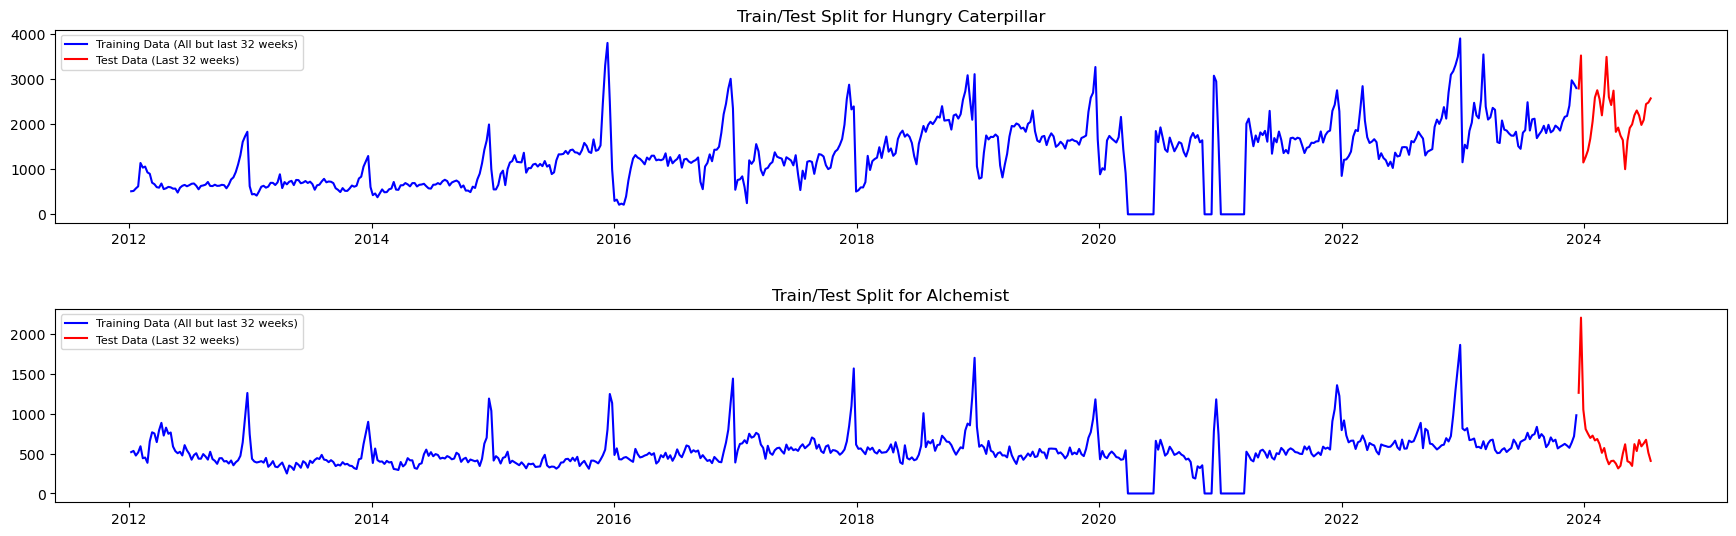

In [8]:
# @ title: Train/Test Split for Both Books
# Plot the sets of training and test dataset for both books
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 6))
ax1.plot(ts_train_hung_caterp.index, ts_train_hung_caterp, label="Training Data (All but last 32 weeks)", color="blue")
ax1.plot(ts_test_hung_caterp.index, ts_test_hung_caterp, label="Test Data (Last 32 weeks)", color="red")
ax1.set_title("Train/Test Split for Hungry Caterpillar")
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(False)

ax2.plot(ts_train_alchemist.index, ts_train_alchemist, label="Training Data (All but last 32 weeks)", color="blue")
ax2.plot(ts_test_alchemist.index, ts_test_alchemist, label="Test Data (Last 32 weeks)", color="red")
ax2.set_title("Train/Test Split for Alchemist")
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(False)

plt.tight_layout(pad=3.0)
plt.show()

# Modeling with LIGHT-GBM

### Modeling The Very Hungry Caterpillar

In [9]:
def create_predictor_base_model():
    regressor = lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1,
        force_row_wise=True,
        min_data_in_leaf=5,          # Increased from 3 for better generalization
        n_estimators=200,            # Increased from 100 for complex patterns
        learning_rate=0.08,          # Slightly lower for stability
        num_leaves=31,               # Control complexity
        feature_fraction=0.8,        # Add regularization
        bagging_fraction=0.8,        # Add regularization
        bagging_freq=5               # Enable bagging
    )
    predictor = make_reduction(
        regressor,
        window_length=52,            # Increased from 12 to capture more seasonality
        strategy="recursive"
    )
    predictor_mult = TransformedTargetForecaster(
        steps=[
            ("deseasonaliser", Deseasonalizer()),
            ("detrender", Detrender()),
            ("forecast", predictor)
        ]
    )
    return predictor

# Updated parameter grid
param_grid = {
    "window_length": [39, 52, 65],   # Weekly data: 9, 12, 15 months
    "estimator__learning_rate": [0.06, 0.08, 0.1],
    "estimator__num_leaves": [15, 31, 63]  # Control model complexity
}

In [10]:
def grid_search_predictor_base_model(train, test, predictor, param_grid):
    cv = ExpandingWindowSplitter(
        initial_window=int(len(train) * 0.6),  # Reduced from 0.7 for more CV folds
        step_length=4                          # Skip 4 weeks between folds for efficiency
    )
    gscv = ForecastingGridSearchCV(
        predictor,
        strategy="refit",
        param_grid=param_grid,
        cv=cv,
        scoring=MeanAbsolutePercentageError(symmetric=True),
        n_jobs=-1,                            # Use all cores for faster search
        verbose=1,                            # Show progress
        error_score='raise'
    )
    gscv.fit(train)
    print(f"Best parameters: {gscv.best_params_}")
    print(f"Best CV score: {gscv.best_score_:.3f}")
    return gscv.predict(fh=np.arange(len(test)) + 1)

# Execute
predictor_lgbm_hc = create_predictor_base_model()
predictions_week_lgbm_hc = grid_search_predictor_base_model(
    ts_train_hung_caterp,
    ts_test_hung_caterp,
    predictor_lgbm_hc,
    param_grid
)

print("Forecasts:", predictions_week_lgbm_hc.head())

Fitting 63 folds for each of 27 candidates, totalling 1701 fits


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/li

Best parameters: {'estimator__learning_rate': 0.08, 'estimator__num_leaves': 63, 'window_length': 52}
Best CV score: 0.373
Forecasts: 2023-12-16    3122.330588
2023-12-23    2835.338253
2023-12-30    1317.719648
2024-01-06    1512.745677
2024-01-13    1568.315860
Freq: W-SAT, Name: Volume, dtype: float64


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

In [11]:
# Step 1: Proper frequency conversion
def prepare_period_data(train, test):
    """Convert to PeriodIndex using W-SAT frequency"""
    train_period = train.to_period('W-SAT')
    test_period = test.to_period('W-SAT')
    return train_period, test_period

def convert_back_to_datetime(predictions, original_test):
    """Convert predictions back to datetime index"""
    predictions_datetime = predictions.to_timestamp('W-SAT')
    # Ensure same index as original test data
    predictions_datetime.index = original_test.index
    return predictions_datetime

In [12]:
# Step 2: Advanced predictor with deseasonalizing + detrending
def create_advanced_predictor():
    """Advanced predictor with deseasonalizing and detrending"""
    
    regressor = lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1,
        force_row_wise=True,
        min_data_in_leaf=5,
        n_estimators=200,
        learning_rate=0.08,  # Will be tuned
        num_leaves=31,       # Will be tuned
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5
    )
    
    predictor = make_reduction(
        regressor,
        window_length=52,    # Will be tuned
        strategy="recursive"
    )
    
    predictor_mult = TransformedTargetForecaster([
        ("deseasonaliser", Deseasonalizer()),
        ("detrender", Detrender()),
        ("forecast", predictor)
    ])

    return predictor_mult

In [13]:
# Step 3: Differencing predictor with TransformedTargetForecaster
def create_differencing_predictor():
    """Predictor with differencing using TransformedTargetForecaster"""

    
    regressor = lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1,
        force_row_wise=True,
        min_data_in_leaf=5,
        n_estimators=200,
        learning_rate=0.08,  # Will be tuned
        num_leaves=31,       # Will be tuned
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5
    )
    
    predictor = make_reduction(
        regressor,
        window_length=52,    # Will be tuned
        strategy="recursive"
    )
    
    predictor_diff = TransformedTargetForecaster([
        ("differencer", Differencer(lags=1)),
        ("forecast", predictor)
    ])

    return predictor_diff

In [14]:
# Step 4: Combined predictor with both differencing AND deseasonalizing
def create_combined_predictor():
    """Ultimate predictor: Differencing + Deseasonalizing + Detrending"""
  
    
    regressor = lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1,
        force_row_wise=True,
        min_data_in_leaf=5,
        n_estimators=200,
        learning_rate=0.08,  # Will be tuned
        num_leaves=31,       # Will be tuned
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5
    )
    
    predictor = make_reduction(
        regressor,
        window_length=52,    # Will be tuned
        strategy="recursive"
    )
    
    predictor_combined = TransformedTargetForecaster([
        ("differencer", Differencer(lags=1)),      # First: remove trend
        ("deseasonaliser", Deseasonalizer()),      # Second: remove seasonality
        ("detrender", Detrender()),                # Third: final detrending
        ("forecast", predictor)                    # Fourth: forecast
    ])
    
    return predictor_combined



In [15]:
# Step 5: Parameter grids with correct naming
def get_param_grid(predictor):
    """Get parameter grid with correct naming based on actual predictor structure"""
    
    # Get all available parameters
    all_params = predictor.get_params()
    
    # Find the correct parameter names by searching
    window_param = None
    learning_rate_param = None
    num_leaves_param = None
    
    for param_name in all_params.keys():
        if 'window_length' in param_name and 'forecast' in param_name:
            window_param = param_name
        elif 'learning_rate' in param_name and 'forecast' in param_name:
            learning_rate_param = param_name
        elif 'num_leaves' in param_name and 'forecast' in param_name:
            num_leaves_param = param_name
    
    print(f"Found parameter names:")
    print(f"  Window length: {window_param}")
    print(f"  Learning rate: {learning_rate_param}")
    print(f"  Num leaves: {num_leaves_param}")
    
    # Build parameter grid with correct names
    param_grid = {}
    
    if window_param:
        param_grid[window_param] = [39, 52, 65]
    if learning_rate_param:
        param_grid[learning_rate_param] = [0.06, 0.08, 0.1]
    if num_leaves_param:
        param_grid[num_leaves_param] = [15, 31, 63]
    
    return param_grid

In [16]:
# Step 6: Universal grid search function
def grid_search_with_frequency_handling(train, test, predictor_type="advanced"):
    """
    Grid search with proper frequency handling
    
    Parameters:
    -----------
    predictor_type: str
        - "advanced": Deseasonalizer + Detrender
        - "differencing": Differencing only  
        - "combined": Differencing + Deseasonalizer + Detrender
    """
    
    print(f"=== Running Grid Search with {predictor_type} predictor ===")
    
    # Convert to period index
    train_period, test_period = prepare_period_data(train, test)
    
    # Create predictor based on type
    if predictor_type == "advanced":
        predictor = create_advanced_predictor()
    elif predictor_type == "differencing":
        predictor = create_differencing_predictor()
    elif predictor_type == "combined":
        predictor = create_combined_predictor()
    else:
        raise ValueError("predictor_type must be 'advanced', 'differencing', or 'combined'")
    
    # Parameter grid
    param_grid = get_param_grid(predictor)

    # Cross-validation setup
    cv = ExpandingWindowSplitter(
        initial_window=int(len(train_period) * 0.6),
        step_length=4
    )
    
    # Grid search
    gscv = ForecastingGridSearchCV(
        predictor,
        strategy="refit",
        param_grid=param_grid,
        cv=cv,
        scoring=MeanAbsolutePercentageError(symmetric=True),
        n_jobs=1,    # Avoid parallel issues
        verbose=1,
        error_score='raise'
    )
    
    try:
        # Fit on period data
        gscv.fit(train_period)
        
        # Predict on period data
        predictions_period = gscv.predict(fh=np.arange(len(test_period)) + 1)
        
        # Convert back to datetime
        predictions_datetime = convert_back_to_datetime(predictions_period, test)
        
        print(f"✅ {predictor_type.title()} Grid Search Successful!")
        print(f"Best parameters: {gscv.best_params_}")
        print(f"Best CV score: {gscv.best_score_:.3f}")
        
        return predictions_datetime, gscv.best_params_, gscv.best_score_
        
    except Exception as e:
        print(f"❌ {predictor_type.title()} Grid Search Failed: {e}")
        return None, None, None


In [17]:
# Step 7: Compare all approaches
def compare_all_approaches(train, test):
    """Compare all three predictor approaches"""
    
    results = {}
    
    # Test each approach
    approaches = ["differencing", "advanced", "combined"]
    
    for approach in approaches:
        print(f"\n{'='*50}")
        predictions, best_params, best_score = grid_search_with_frequency_handling(
            train, test, predictor_type=approach
        )
        
        if predictions is not None:
            results[approach] = {
                'predictions': predictions,
                'best_params': best_params,
                'best_score': best_score
            }
        
    # Find best approach
    if results:
        best_approach = min(results.keys(), key=lambda k: results[k]['best_score'])
        
        print(f"\n🏆 BEST APPROACH: {best_approach}")
        print(f"Best CV Score: {results[best_approach]['best_score']:.4f}")
        print(f"Best Parameters: {results[best_approach]['best_params']}")
        
        return results[best_approach]['predictions'], results
    
    else:
        print("❌ All approaches failed!")
        return None, {}

In [18]:
# Test just differencing
predictions_diff, params, score = grid_search_with_frequency_handling(
    ts_train_hung_caterp, 
    ts_test_hung_caterp, 
    predictor_type="differencing"
)

=== Running Grid Search with differencing predictor ===
Found parameter names:
  Window length: forecast__window_length
  Learning rate: forecast__estimator__learning_rate
  Num leaves: forecast__estimator__num_leaves
Fitting 63 folds for each of 27 candidates, totalling 1701 fits


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/li

✅ Differencing Grid Search Successful!
Best parameters: {'forecast__estimator__learning_rate': 0.1, 'forecast__estimator__num_leaves': 31, 'forecast__window_length': 65}
Best CV score: 0.381


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

In [19]:
# Test just advanced (deseasonalizing)
predictions_deseas_detren, params, score = grid_search_with_frequency_handling(
    ts_train_hung_caterp, 
    ts_test_hung_caterp, 
    predictor_type="advanced"  
)

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


=== Running Grid Search with advanced predictor ===
Found parameter names:
  Window length: forecast__window_length
  Learning rate: forecast__estimator__learning_rate
  Num leaves: forecast__estimator__num_leaves
Fitting 63 folds for each of 27 candidates, totalling 1701 fits


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

✅ Advanced Grid Search Successful!
Best parameters: {'forecast__estimator__learning_rate': 0.08, 'forecast__estimator__num_leaves': 31, 'forecast__window_length': 65}
Best CV score: 0.356


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

In [20]:
# Test combined approach
predictions_diff_desea_detren, params, score = grid_search_with_frequency_handling(
    ts_train_hung_caterp, 
    ts_test_hung_caterp, 
    predictor_type="combined"
)

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


=== Running Grid Search with combined predictor ===
Found parameter names:
  Window length: forecast__window_length
  Learning rate: forecast__estimator__learning_rate
  Num leaves: forecast__estimator__num_leaves
Fitting 63 folds for each of 27 candidates, totalling 1701 fits


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

✅ Combined Grid Search Successful!
Best parameters: {'forecast__estimator__learning_rate': 0.06, 'forecast__estimator__num_leaves': 31, 'forecast__window_length': 65}
Best CV score: 0.377


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

### Modeling The Alchemist

In [21]:
def create_predictor_base_model():
    regressor = lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1,
        force_row_wise=True,
        min_data_in_leaf=5,          # Increased from 3 for better generalization
        n_estimators=200,            # Increased from 100 for complex patterns
        learning_rate=0.08,          # Slightly lower for stability
        num_leaves=31,               # Control complexity
        feature_fraction=0.8,        # Add regularization
        bagging_fraction=0.8,        # Add regularization
        bagging_freq=5               # Enable bagging
    )
    predictor = make_reduction(
        regressor,
        window_length=52,            # Increased from 12 to capture more seasonality
        strategy="recursive"
    )
    predictor_mult = TransformedTargetForecaster(
        steps=[
            ("deseasonaliser", Deseasonalizer()),
            ("detrender", Detrender()),
            ("forecast", predictor)
        ]
    )
    return predictor

# Updated parameter grid
param_grid = {
    "window_length": [39, 52, 65],   # Weekly data: 9, 12, 15 months
    "estimator__learning_rate": [0.06, 0.08, 0.1],
    "estimator__num_leaves": [15, 31, 63]  # Control model complexity
}

In [22]:
def grid_search_predictor_base_model(train, test, predictor, param_grid):
    cv = ExpandingWindowSplitter(
        initial_window=int(len(train) * 0.6),  # Reduced from 0.7 for more CV folds
        step_length=4                          # Skip 4 weeks between folds for efficiency
    )
    gscv = ForecastingGridSearchCV(
        predictor,
        strategy="refit",
        param_grid=param_grid,
        cv=cv,
        scoring=MeanAbsolutePercentageError(symmetric=True),
        n_jobs=-1,                            # Use all cores for faster search
        verbose=1,                            # Show progress
        error_score='raise'
    )
    gscv.fit(train)
    print(f"Best parameters: {gscv.best_params_}")
    print(f"Best CV score: {gscv.best_score_:.3f}")
    return gscv.predict(fh=np.arange(len(test)) + 1)

# Execute
predictor_lgbm_alchemist = create_predictor_base_model()
predictions_week_lgbm_alchemist = grid_search_predictor_base_model(
    ts_train_alchemist,
    ts_test_alchemist,
    predictor_lgbm_alchemist,
    param_grid
)

print("Forecasts:", predictions_week_lgbm_alchemist.head())

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


Fitting 63 folds for each of 27 candidates, totalling 1701 fits


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

Best parameters: {'estimator__learning_rate': 0.06, 'estimator__num_leaves': 15, 'window_length': 52}
Best CV score: 0.365
Forecasts: 2023-12-16    1265.567389
2023-12-23    1681.950108
2023-12-30     960.232589
2024-01-06     729.581775
2024-01-13     691.201845
Freq: W-SAT, Name: Volume, dtype: float64


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

In [23]:
# Modeling the alchemist with differencing
predictions_diff_alchemist, params_alchemist_diff, score_alchemist_diff = grid_search_with_frequency_handling(
    ts_train_alchemist, 
    ts_test_alchemist, 
    predictor_type="differencing"
)

=== Running Grid Search with differencing predictor ===
Found parameter names:
  Window length: forecast__window_length
  Learning rate: forecast__estimator__learning_rate
  Num leaves: forecast__estimator__num_leaves
Fitting 63 folds for each of 27 candidates, totalling 1701 fits


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/li

✅ Differencing Grid Search Successful!
Best parameters: {'forecast__estimator__learning_rate': 0.1, 'forecast__estimator__num_leaves': 15, 'forecast__window_length': 39}
Best CV score: 0.379


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

In [24]:
# Modeling the alchemist with deseasonalizing and detrending
predictions_deseas_detren_alchemist, params_alchemist_deseas_detren, score_alchemist_deseas_detren = grid_search_with_frequency_handling(
    ts_train_alchemist, 
    ts_test_alchemist, 
    predictor_type="advanced"
)

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


=== Running Grid Search with advanced predictor ===
Found parameter names:
  Window length: forecast__window_length
  Learning rate: forecast__estimator__learning_rate
  Num leaves: forecast__estimator__num_leaves
Fitting 63 folds for each of 27 candidates, totalling 1701 fits


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

✅ Advanced Grid Search Successful!
Best parameters: {'forecast__estimator__learning_rate': 0.08, 'forecast__estimator__num_leaves': 15, 'forecast__window_length': 52}
Best CV score: 0.357


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

In [25]:
# Modeling the alchemist with differencing, deseasonalizing and detrending
predictions_diff_deseas_detren_alchemist, params_alchemist_diff_deseas_detren, score_alchemist_diff_deseas_detren = grid_search_with_frequency_handling(
    ts_train_alchemist, 
    ts_test_alchemist, 
    predictor_type="combined"
)


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sktime/forecasting/model_selection/_tune.py:90: UserWarning: Parameter n_jobs of ForecastingGridSearchCV has been removed in sktime 0.27.0 and is no longer used. It is ignored when passed. Instead, the backend and backend_params parameters should be used to pass n_jobs or other parallelization parameters.
  warn(


=== Running Grid Search with combined predictor ===
Found parameter names:
  Window length: forecast__window_length
  Learning rate: forecast__estimator__learning_rate
  Num leaves: forecast__estimator__num_leaves
Fitting 63 folds for each of 27 candidates, totalling 1701 fits


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

✅ Combined Grid Search Successful!
Best parameters: {'forecast__estimator__learning_rate': 0.06, 'forecast__estimator__num_leaves': 15, 'forecast__window_length': 52}
Best CV score: 0.377


/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/ts/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warni

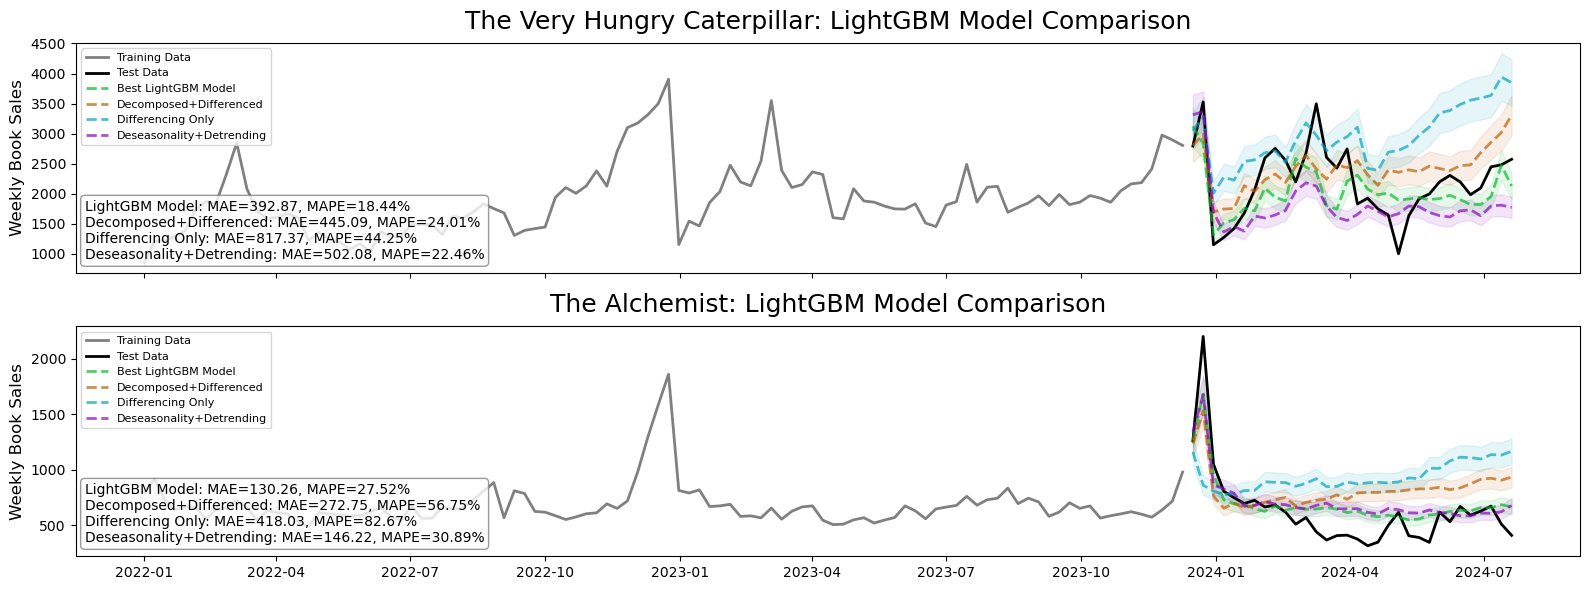

In [55]:
# Control the display period here
training_start_date = '2022-01-01'  # Change this to control what period is displayed

# Set up figure and subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(16, 6), sharex=True)
plt.subplots_adjust(hspace=0.4)

#====================== Plot The Very Hungry Caterpillar ============================================
# Training and test data - using training_start_date to control display period
ax1.plot(ts_train_hung_caterp[ts_train_hung_caterp.index >= training_start_date],
         label='Training Data', color='gray', linewidth=2)
ax1.plot(ts_test_hung_caterp[ts_test_hung_caterp.index >= training_start_date],
         label='Test Data', color='black', linewidth=2)

# Model predictions with individual styling - filtered by training_start_date
test_dates_hc = ts_test_hung_caterp[ts_test_hung_caterp.index >= training_start_date].index

# Plot each model's predictions
models_hc = [
    (predictions_week_lgbm_hc, 'Best LightGBM Model', '#06bb30'),
    (predictions_diff_desea_detren, 'Decomposed+Differenced', '#bb6006'),
    (predictions_diff, 'Differencing Only', '#06a3bb'),
    (predictions_deseas_detren, 'Deseasonality+Detrending', '#8b06bb')
]

for pred, label, color in models_hc:
    ax1.plot(test_dates_hc, pred[ts_test_hung_caterp.index >= training_start_date],
             label=label,
             linestyle='--',
             linewidth=2,
             color=color,
             alpha=0.7)
    ax1.fill_between(test_dates_hc,
                    pred[ts_test_hung_caterp.index >= training_start_date] * 0.9,
                    pred[ts_test_hung_caterp.index >= training_start_date] * 1.1,
                    color=color, alpha=0.1)

# Calculate and display metrics
metrics_text_hc = "\n".join([
    f"LightGBM Model: MAE={mean_absolute_error(ts_test_hung_caterp, predictions_week_lgbm_hc):.2f}, MAPE={mean_absolute_percentage_error(ts_test_hung_caterp, predictions_week_lgbm_hc):.2%}",
    f"Decomposed+Differenced: MAE={mean_absolute_error(ts_test_hung_caterp, predictions_diff_desea_detren):.2f}, MAPE={mean_absolute_percentage_error(ts_test_hung_caterp, predictions_diff_desea_detren):.2%}",
    f"Differencing Only: MAE={mean_absolute_error(ts_test_hung_caterp, predictions_diff):.2f}, MAPE={mean_absolute_percentage_error(ts_test_hung_caterp, predictions_diff):.2%}",
    f"Deseasonality+Detrending: MAE={mean_absolute_error(ts_test_hung_caterp, predictions_deseas_detren):.2f}, MAPE={mean_absolute_percentage_error(ts_test_hung_caterp, predictions_deseas_detren):.2%}"
])

ax1.annotate(metrics_text_hc, xy=(0.006, 0.32), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
             fontsize=10, va='top', ha='left')

# Formatting
ax1.set_title('The Very Hungry Caterpillar: LightGBM Model Comparison', pad=10, fontsize=18)
ax1.set_ylabel('Weekly Book Sales', fontsize=12)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(False)

#====================== Plot The Alchemist ============================================
# Training and test data - using training_start_date to control display period
ax2.plot(ts_train_alchemist[ts_train_alchemist.index >= training_start_date],
         label='Training Data', color='gray', linewidth=2)
ax2.plot(ts_test_alchemist[ts_test_alchemist.index >= training_start_date],
         label='Test Data', color='black', linewidth=2)

# Model predictions with individual styling - filtered by training_start_date
test_dates_al = ts_test_alchemist[ts_test_alchemist.index >= training_start_date].index

# Plot each model's predictions
models_al = [
    (predictions_week_lgbm_alchemist, 'Best LightGBM Model', '#06bb30'),
    (predictions_diff_deseas_detren_alchemist, 'Decomposed+Differenced', '#bb6006'),
    (predictions_diff_alchemist, 'Differencing Only', '#06a3bb'),
    (predictions_deseas_detren_alchemist, 'Deseasonality+Detrending', '#8b06bb')
]

for pred, label, color in models_al:
    ax2.plot(test_dates_al, pred[ts_test_alchemist.index >= training_start_date],
             label=label,
             linestyle='--',
             linewidth=2,
             color=color,
             alpha=0.7)
    ax2.fill_between(test_dates_al,
                    pred[ts_test_alchemist.index >= training_start_date] * 0.9,
                    pred[ts_test_alchemist.index >= training_start_date] * 1.1,
                    color=color, alpha=0.1)

# Calculate and display metrics
metrics_text_al = "\n".join([
    f"LightGBM Model: MAE={mean_absolute_error(ts_test_alchemist, predictions_week_lgbm_alchemist):.2f}, MAPE={mean_absolute_percentage_error(ts_test_alchemist, predictions_week_lgbm_alchemist):.2%}",
    f"Decomposed+Differenced: MAE={mean_absolute_error(ts_test_alchemist, predictions_diff_deseas_detren_alchemist):.2f}, MAPE={mean_absolute_percentage_error(ts_test_alchemist, predictions_diff_deseas_detren_alchemist):.2%}",
    f"Differencing Only: MAE={mean_absolute_error(ts_test_alchemist, predictions_diff_alchemist):.2f}, MAPE={mean_absolute_percentage_error(ts_test_alchemist, predictions_diff_alchemist):.2%}",
    f"Deseasonality+Detrending: MAE={mean_absolute_error(ts_test_alchemist, predictions_deseas_detren_alchemist):.2f}, MAPE={mean_absolute_percentage_error(ts_test_alchemist, predictions_deseas_detren_alchemist):.2%}"
])

ax2.annotate(metrics_text_al, xy=(0.006, 0.32), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
             fontsize=10, va='top', ha='left')

# Formatting
ax2.set_title('The Alchemist: LightGBM Model Comparison', pad=10, fontsize=18)
ax2.set_ylabel('Weekly Book Sales', fontsize=12)
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(False)

plt.tight_layout()
plt.show()

# LSTM Modeling

In [27]:
# Import necessary libraries for saving the plots
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from kerastuner.tuners import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from tensorflow.keras.layers import Input
from sklearn.model_selection import TimeSeriesSplit
from keras_tuner import RandomSearch
import keras_tuner as kt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from datetime import datetime, timedelta
from keras_tuner import BayesianOptimization
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.base import BaseEstimator, TransformerMixin
tf.random.set_seed(0)

/opt/miniconda3/envs/ts/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/var/folders/fw/y66wb9yj5c72qt_vyyz__c2r0000gn/T/ipykernel_38230/3612352308.py:6: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner.tuners import RandomSearch


### Modeling The Very Hungry Caterpillar

### No Preprocessing

In [28]:
# This class is designed to handle multi-step LSTM forecasting with a focus on simplicity and efficiency.
class MultiStepLSTMForecaster:
    """
    A streamlined class for multi-step LSTM time series forecasting
    """
    def __init__(self, lookback=52, forecast=32, lstm_units=[128, 64], dropout_rate=0.2):
        self.lookback = lookback
        self.forecast = forecast
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.scaler = None
        self.model = None
        self.history = None
        
    def prepare_data(self, ts_train, ts_test=None):
        """
        Prepare and normalize time series data
        
        Args:
            ts_train: Training time series data (pandas Series)
            ts_test: Test time series data (pandas Series, optional)
        
        Returns:
            Tuple of processed data
        """
        # Reshape data
        train_reshaped = ts_train.values.reshape(-1, 1)
        
        # Initialize and fit scaler on training data
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        train_scaled = self.scaler.fit_transform(train_reshaped)
        
        # Process test data if provided
        test_scaled = None
        if ts_test is not None:
            test_reshaped = ts_test.values.reshape(-1, 1)
            test_scaled = self.scaler.transform(test_reshaped)
        
        return train_scaled, test_scaled
    
    def create_sequences(self, data, mode='train'):
        """
        Create sequences for multi-step forecasting
        
        Args:
            data: Scaled time series data
            mode: 'train' or 'test'
        
        Returns:
            input_sequences, output_sequences
        """
        input_sequences = []
        output_sequences = []
        
        if mode == 'train':
            # Validate data length
            if len(data) < self.lookback + self.forecast:
                raise ValueError(f"Training needs {self.lookback + self.forecast} points, got {len(data)}")
            
            # Create overlapping sequences for training
            for i in range(len(data) - self.lookback - self.forecast + 1):
                input_sequences.append(data[i:i+self.lookback])
                output_sequences.append(data[i+self.lookback:i+self.lookback+self.forecast].flatten())
                
        else:  # test mode
            # Pad with zeros if needed
            if len(data) < self.lookback:
                padded_data = np.zeros((self.lookback, 1))
                padded_data[-len(data):] = data
                data = padded_data
            
            # Create one sequence from the end of the data
            input_sequences.append(data[-self.lookback:])
            output_sequences.append(np.array([]))  # Empty for test
        
        return np.array(input_sequences), np.array(output_sequences)
    
    def build_model(self, architecture='simple'):
        """
        Build the multi-step LSTM model
        
        Args:
            architecture: 'simple' (original working) or 'complex' (enhanced)
        """
        model = Sequential()
        if architecture == 'simple':
            # Original working architecture - simpler and often better for time series
            model.add(LSTM(self.lstm_units[0], 
                          return_sequences=len(self.lstm_units) > 1,
                          input_shape=(self.lookback, 1)))
            model.add(Dropout(self.dropout_rate))
            
            # Additional LSTM layers
            for i, units in enumerate(self.lstm_units[1:], 1):
                return_seq = i < len(self.lstm_units) - 1
                model.add(LSTM(units, return_sequences=return_seq))
                model.add(Dropout(self.dropout_rate))
            
            # Direct output layer
            model.add(Dense(self.forecast))
            
            # Simple optimizer
            model.compile(optimizer=Adam(learning_rate=0.001),
                         loss='mse',
                         metrics=['mae'])
        
        else:  # complex architecture
            # Enhanced architecture with more regularization
            model.add(LSTM(self.lstm_units[0], 
                          return_sequences=True,
                          input_shape=(self.lookback, 1),
                          recurrent_dropout=0.1))
            model.add(Dropout(self.dropout_rate))
            
            for i, units in enumerate(self.lstm_units[1:], 1):
                return_seq = i < len(self.lstm_units) - 1
                model.add(LSTM(units, return_sequences=return_seq, recurrent_dropout=0.1))
                model.add(Dropout(self.dropout_rate))
            
            # Additional dense layer
            model.add(Dense(64, activation='relu'))
            model.add(Dropout(self.dropout_rate))
            model.add(Dense(self.forecast, activation='linear'))
            
            # Enhanced optimizer
            model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
                         loss='mse',
                         metrics=['mae'])
        
        self.model = model
        return model
    
    def train(self, X_train, y_train, batch_size=16, epochs=100, validation_split=0.2, 
              early_stopping=True, patience=25, verbose=1):
        """
        Train the LSTM model with optimal settings
        """
        if self.model is None:
            self.build_model()
        
        callbacks = []
        
        if early_stopping:
            callbacks.extend([
                EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, min_delta=1e-6),
                ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=15, min_lr=1e-8, verbose=1)
            ])
        
        self.history = self.model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=verbose
        )
        
        return self.history
    
    def predict(self, X_test):
        """
        Make predictions and inverse transform to original scale
        """
        if self.model is None:
            raise ValueError("Model must be trained before making predictions")
        
        # Ensure tensor consistency to avoid retracing warnings
        X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)
        
        # Make predictions
        predictions_scaled = self.model.predict(X_test_tensor, verbose=0)
        
        # Inverse transform to original scale
        predictions_reshaped = predictions_scaled.reshape(-1, 1)
        predictions_original = self.scaler.inverse_transform(predictions_reshaped).flatten()
        
        return predictions_original
    
    def create_forecast_dataframe(self, predictions, last_date, freq='W-SAT'):
        """
        Create a formatted DataFrame with forecast dates and predictions
        """
        forecast_dates = pd.date_range(
            start=last_date + pd.Timedelta(weeks=1),
            periods=len(predictions),
            freq=freq
        )
        
        forecast_df = pd.DataFrame({
            'Date': forecast_dates,
            'Predictions': predictions
        }).set_index('Date')
        
        return forecast_df



In [29]:
def run_lstm_forecast(ts_train, ts_test=None, lookback=52, forecast=32, 
                     lstm_units=[128, 64], dropout_rate=0.2, epochs=100, 
                     early_stopping=False, architecture='simple'):
    """
    Complete streamlined LSTM forecasting workflow
    
    Args:
        ts_train: Training time series (pandas Series)
        ts_test: Test time series (pandas Series, optional)
        lookback: Number of input timesteps
        forecast: Number of output timesteps
        lstm_units: List of LSTM layer sizes
        dropout_rate: Dropout rate
        epochs: Training epochs
        early_stopping: Whether to use early stopping
        architecture: 'simple' or 'complex' model architecture
    
    Returns:
        forecaster, predictions_df, history
    """
    
    # Initialize forecaster
    forecaster = MultiStepLSTMForecaster(
        lookback=lookback,
        forecast=forecast,
        lstm_units=lstm_units,
        dropout_rate=dropout_rate
    )
    
    # Prepare data
    train_scaled, test_scaled = forecaster.prepare_data(ts_train, ts_test)
    
    # Create sequences
    X_train, y_train = forecaster.create_sequences(train_scaled, mode='train')
    X_test, _ = forecaster.create_sequences(train_scaled, mode='test')
    
    print(f"Training sequences: X_train {X_train.shape}, y_train {y_train.shape}")
    print(f"Test sequences: X_test {X_test.shape}")
    print(f"Using {architecture} architecture")
    
    # Build and train model with specified architecture
    forecaster.build_model(architecture=architecture)
    history = forecaster.train(X_train, y_train, epochs=epochs, early_stopping=early_stopping)
    
    # Make predictions
    predictions = forecaster.predict(X_test)
    
    # Create forecast DataFrame
    predictions_df = forecaster.create_forecast_dataframe(
        predictions, ts_train.index[-1]
    )
    
    print(f"\n{forecast}-week forecast:")
    print(predictions_df.head())
    print(f"Prediction range: {predictions.min():.2f} to {predictions.max():.2f}")
    
    return forecaster, predictions_df, history



In [30]:
# Example usage - now defaults to the working simple architecture
forecaster_hc_lstm_base_model, predictions_df_hc_lstm_base, history_hc_lstm_base = run_lstm_forecast(
    ts_train=ts_train_hung_caterp,
    ts_test=ts_test_hung_caterp,
    lookback=52,
    forecast=32,
    epochs=100,
    architecture='simple'  # Use the working architecture
)

# For experimentation, we can also try:
# architecture='complex' for the enhanced version
# early_stopping=True if we want early stopping
# dropout_rate=0.1 for less regularization
# lstm_units=[256, 128] for more capacity

# Method 2: Direct class usage matching your working approach
# forecaster = MultiStepLSTMForecaster(lookback=52, forecast=32)
# train_scaled, _ = forecaster.prepare_data(ts_train_hung_caterp)
# X_train, y_train = forecaster.create_sequences(train_scaled, mode='train')
# X_test, _ = forecaster.create_sequences(train_scaled, mode='test')

# # Build with simple architecture (matches your working code)
# forecaster.build_model(architecture='simple')

# # Train without early stopping (like your working code)
# history = forecaster.train(X_train, y_train, epochs=100, early_stopping=False, 
#                           batch_size=16, validation_split=0.2)

# predictions = forecaster.predict(X_test)
# predictions_df = forecaster.create_forecast_dataframe(predictions, ts_train_hung_caterp.index[-1])

Training sequences: X_train (540, 52, 1), y_train (540, 32)
Test sequences: X_test (1, 52, 1)
Using simple architecture
Epoch 1/100
27/27 [==============================] - 2s 45ms/step - loss: 0.0570 - mae: 0.1866 - val_loss: 0.0319 - val_mae: 0.1271
Epoch 2/100
27/27 [==============================] - 1s 30ms/step - loss: 0.0309 - mae: 0.1313 - val_loss: 0.0363 - val_mae: 0.1377
Epoch 3/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0304 - mae: 0.1299 - val_loss: 0.0401 - val_mae: 0.1474
Epoch 4/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0295 - mae: 0.1282 - val_loss: 0.0378 - val_mae: 0.1420
Epoch 5/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0290 - mae: 0.1269 - val_loss: 0.0386 - val_mae: 0.1438
Epoch 6/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0280 - mae: 0.1235 - val_loss: 0.0449 - val_mae: 0.1607
Epoch 7/100
27/27 [==============================] - 1s 32ms/step - loss: 0.0276 - mae: 

### With Preprocessing

In [31]:
# This class provides a flexible transformer for time series preprocessing, allowing deseasonalizing, detrending, differencing, and auto-detection of the best method based on the data characteristics.
class TimeSeriesTransformer(BaseEstimator, TransformerMixin):
    """Transformer for time series preprocessing (deseasonalizing, detrending, differencing, and auto-detection of method)"""
    
    def __init__(self, method='difference', seasonal_period=52, difference_lags=None):
        """
        Args:
            method: 'deseasonalize', 'detrend', 'difference', or 'auto'
            seasonal_period: period for seasonal decomposition
            difference_lags: lags for differencing (None for auto)
        """
        self.method = method
        self.seasonal_period = seasonal_period
        self.difference_lags = difference_lags
        self.seasonal_component_ = None
        self.trend_component_ = None
        self.initial_values_ = None  # For differencing inversion
        self.required_differences_ = 0
        
    def fit(self, X, y=None):
        """Fit the transformer to the data"""
        X = X.flatten()  # Ensure 1D array
        if self.method == 'auto':
            self._determine_best_method(X)
        return self
    
    def transform(self, X):
        """Apply the transformation to the data"""
        X = X.flatten()  # Ensure 1D array
        if self.method == 'deseasonalize':
            return self._deseasonalize(X)
        elif self.method == 'detrend':
            return self._detrend(X)
        elif self.method == 'difference':
            return self._difference(X)
        elif self.method == 'auto':
            return self._auto_transform(X)
        return X
    
    def inverse_transform(self, X):
        """Reverse the transformation on the data"""
        X = X.flatten()  # Ensure 1D array
        if self.method == 'deseasonalize' and self.seasonal_component_ is not None:
            return X + self.seasonal_component_[-len(X):]
        elif self.method == 'detrend' and self.trend_component_ is not None:
            return X + self.trend_component_[-len(X):]
        elif self.method == 'difference' and self.initial_values_ is not None:
            # Reconstruct original series from differences
            return np.concatenate([self.initial_values_, X]).cumsum()[-len(X):]
        return X
    
    def _deseasonalize(self, X):
        """Remove seasonal component"""
        decomposition = seasonal_decompose(
            X, 
            period=self.seasonal_period, 
            model='additive',
            extrapolate_trend='freq'  # Handle edge effects
        )
        self.seasonal_component_ = decomposition.seasonal
        return X - self.seasonal_component_
    
    def _detrend(self, X):
        """Remove trend component"""
        decomposition = seasonal_decompose(
            X,
            period=self.seasonal_period,
            model='additive',
            extrapolate_trend='freq'
        )
        self.trend_component_ = decomposition.trend
        return X - self.trend_component_
    
    def _difference(self, X):
        """Apply differencing"""
        if self.difference_lags is None:
            self.initial_values_ = X[:1]  # Store first value
            return np.diff(X, n=1)
        else:
            self.initial_values_ = X[:self.difference_lags]
            return np.diff(X, n=self.difference_lags)
    
    def _determine_best_method(self, X):
        """Automatically determine the best transformation method"""
        # Check stationarity
        result = adfuller(X)
        if result[1] > 0.05:  # Not stationary
            self.required_differences_ = 1
            self.method = 'difference'
        else:
            # Check for seasonality
            try:
                decomposition = seasonal_decompose(
                    X,
                    period=self.seasonal_period,
                    model='additive',
                    extrapolate_trend='freq'
                )
                seasonal_strength = np.abs(decomposition.seasonal).mean() / np.abs(decomposition.resid).mean()
                if seasonal_strength > 0.5:
                    self.method = 'deseasonalize'
                else:
                    self.method = 'detrend'
            except ValueError:
                # Fallback if decomposition fails
                self.method = 'detrend'
    
    def _auto_transform(self, X):
        """Apply automatically determined transformation"""
        if self.method == 'difference':
            return self._difference(X)
        elif self.method == 'deseasonalize':
            return self._deseasonalize(X)
        else:  # detrend
            return self._detrend(X)

In [62]:
# This class is designed to handle multi-step LSTM forecasting with time series preprocessing capabilities, including deseasonalizing, detrending, and differencing.
class MultiStepLSTMForecasterWithPreprocessing:
    """
    Enhanced LSTM forecaster with time series preprocessing
    """
    def __init__(self, lookback=52, forecast=32, lstm_units=[128, 64], dropout_rate=0.2,
                 preprocessing_method='auto'):
        self.lookback = lookback
        self.forecast = forecast
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.preprocessing_method = preprocessing_method
        self.scaler = None
        self.transformer = None
        self.model = None
        self.history = None
        
    def prepare_data(self, ts_train, ts_test=None):
        """
        Prepare and preprocess time series data
        """
        # Initialize transformer
        self.transformer = TimeSeriesTransformer(method=self.preprocessing_method)
        
        # Reshape and transform data (ensure we work with 1D array)
        train_values = ts_train.values.flatten()
        self.transformer.fit(train_values.reshape(-1, 1))
        train_transformed = self.transformer.transform(train_values.reshape(-1, 1)).flatten()
        
        # Initialize and fit scaler on transformed training data
        self.scaler = MinMaxScaler(feature_range=(0, 1))
        train_scaled = self.scaler.fit_transform(train_transformed.reshape(-1, 1)).flatten()
        
        # Process test data if provided
        test_scaled = None
        if ts_test is not None:
            test_values = ts_test.values.flatten()
            test_transformed = self.transformer.transform(test_values.reshape(-1, 1)).flatten()
            test_scaled = self.scaler.transform(test_transformed.reshape(-1, 1)).flatten()
        
        return train_scaled, test_scaled
    
    def create_sequences(self, data, mode='train'):
        """
        Create sequences for multi-step forecasting
        """
        input_sequences = []
        output_sequences = []
        
        if mode == 'train':
            # Validate data length
            if len(data) < self.lookback + self.forecast:
                raise ValueError(f"Training needs {self.lookback + self.forecast} points, got {len(data)}")
            
            # Create overlapping sequences for training
            for i in range(len(data) - self.lookback - self.forecast + 1):
                input_sequences.append(data[i:i+self.lookback])
                output_sequences.append(data[i+self.lookback:i+self.lookback+self.forecast])
                
        else:  # test mode
            # Pad with zeros if needed
            if len(data) < self.lookback:
                padded_data = np.zeros(self.lookback)
                padded_data[-len(data):] = data
                data = padded_data
            
            # Create one sequence from the end of the data
            input_sequences.append(data[-self.lookback:])
            output_sequences.append(np.array([]))  # Empty for test
        
        # Reshape for LSTM (samples, timesteps, features)
        X = np.array(input_sequences).reshape(-1, self.lookback, 1)
        y = np.array(output_sequences)
        
        return X, y
    
    def inverse_transform_predictions(self, predictions):
        """
        Inverse transform predictions through scaler and time series transformer
        """
        # Inverse scale
        predictions_reshaped = predictions.reshape(-1, 1)
        predictions_scaled = self.scaler.inverse_transform(predictions_reshaped).flatten()
        
        # Inverse time series transform
        predictions_original = self.transformer.inverse_transform(predictions_scaled)
        
        return predictions_original
    
    
    def build_model(self, architecture='simple'):
        """
        Build the multi-step LSTM model
        
        Args:
            architecture: 'simple' (original working) or 'complex' (enhanced)
        """
        model = Sequential()
        if architecture == 'simple':
            # Original working architecture - simpler and often better for time series
            model.add(LSTM(self.lstm_units[0], 
                          return_sequences=len(self.lstm_units) > 1,
                          input_shape=(self.lookback, 1)))
            model.add(Dropout(self.dropout_rate))
            
            # Additional LSTM layers
            for i, units in enumerate(self.lstm_units[1:], 1):
                return_seq = i < len(self.lstm_units) - 1
                model.add(LSTM(units, return_sequences=return_seq))
                model.add(Dropout(self.dropout_rate))
            
            # Direct output layer
            model.add(Dense(self.forecast))
            
            # Simple optimizer
            model.compile(optimizer=Adam(learning_rate=0.001),
                         loss='mse',
                         metrics=['mae'])
        
        else:  # complex architecture
            # Enhanced architecture with more regularization
            model.add(LSTM(self.lstm_units[0], 
                          return_sequences=True,
                          input_shape=(self.lookback, 1),
                          recurrent_dropout=0.1))
            model.add(Dropout(self.dropout_rate))
            
            for i, units in enumerate(self.lstm_units[1:], 1):
                return_seq = i < len(self.lstm_units) - 1
                model.add(LSTM(units, return_sequences=return_seq, recurrent_dropout=0.1))
                model.add(Dropout(self.dropout_rate))
            
            # Additional dense layer
            model.add(Dense(64, activation='relu'))
            model.add(Dropout(self.dropout_rate))
            model.add(Dense(self.forecast, activation='linear'))
            
            # Enhanced optimizer
            model.compile(optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
                         loss='mse',
                         metrics=['mae'])
        
        self.model = model
        return model
    
    def train(self, X_train, y_train, batch_size=16, epochs=100, validation_split=0.2, 
              early_stopping=True, patience=25, verbose=1):
        """
        Train the LSTM model with optimal settings
        """
        if self.model is None:
            self.build_model()
        
        callbacks = []
        
        if early_stopping:
            callbacks.extend([
                EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, min_delta=1e-6),
                ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=15, min_lr=1e-8, verbose=1)
            ])
        
        self.history = self.model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=epochs,
            validation_split=validation_split,
            callbacks=callbacks,
            verbose=verbose
        )
        
        return self.history
    
    
    def predict(self, X_test):
        """
        Make predictions and inverse transform to original scale
        """
        if self.model is None:
            raise ValueError("Model must be trained before making predictions")
        
        # Ensure tensor consistency to avoid retracing warnings
        X_test_tensor = tf.convert_to_tensor(X_test, dtype=tf.float32)
        
        # Make predictions
        predictions_scaled = self.model.predict(X_test_tensor, verbose=0)
        
        # Inverse transform through all steps
        predictions_original = self.inverse_transform_predictions(predictions_scaled)
        
        return predictions_original
    
    def create_forecast_dataframe(self, predictions, last_date, freq='W-SAT'):
        """
        Create a formatted DataFrame with forecast dates and predictions
        """
        forecast_dates = pd.date_range(
            start=last_date + pd.Timedelta(weeks=1),
            periods=len(predictions),
            freq=freq
        )
        
        forecast_df = pd.DataFrame({
            'Date': forecast_dates,
            'Predictions': predictions
        }).set_index('Date')
        
        return forecast_df

In [63]:
def run_lstm_forecast_with_preprocessing(ts_train, ts_test=None, lookback=52, forecast=32,
                                        lstm_units=[128, 64], dropout_rate=0.2, epochs=100,
                                        preprocessing_method='auto', architecture='simple'):
    """
    Complete LSTM forecasting workflow with preprocessing
    """
    # Initialize forecaster
    forecaster = MultiStepLSTMForecasterWithPreprocessing(
        lookback=lookback,
        forecast=forecast,
        lstm_units=lstm_units,
        dropout_rate=dropout_rate,
        preprocessing_method=preprocessing_method
    )
    
    # Prepare data with preprocessing
    train_scaled, test_scaled = forecaster.prepare_data(ts_train, ts_test)
    
    # Create sequences
    X_train, y_train = forecaster.create_sequences(train_scaled, mode='train')
    X_test, _ = forecaster.create_sequences(train_scaled, mode='test')
    
    # Build and train model
    forecaster.build_model(architecture=architecture)
    history = forecaster.train(X_train, y_train, epochs=epochs)
    
    # Make predictions (automatically inverse transforms)
    predictions = forecaster.predict(X_test)
    
    # Create forecast DataFrame
    predictions_df = forecaster.create_forecast_dataframe(
        predictions, ts_train.index[-1]
    )
    
    return forecaster, predictions_df, history



In [34]:
# Differencing
forecaster_hc_lstm_diff, predictions_df_hc_lstm_diff, history_hc_lstm_diff = run_lstm_forecast_with_preprocessing(
    ts_train=ts_train_hung_caterp,
    lookback=52,
    forecast=32,
    lstm_units=[128, 64],
    dropout_rate=0.2,
    epochs=100,
    preprocessing_method='difference',
    architecture='simple'
)

Epoch 1/100
27/27 [==============================] - 3s 58ms/step - loss: 0.0871 - mae: 0.2379 - val_loss: 0.0068 - val_mae: 0.0581 - lr: 0.0010
Epoch 2/100
27/27 [==============================] - 1s 41ms/step - loss: 0.0199 - mae: 0.1086 - val_loss: 0.0077 - val_mae: 0.0681 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 1s 43ms/step - loss: 0.0144 - mae: 0.0914 - val_loss: 0.0057 - val_mae: 0.0487 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 1s 44ms/step - loss: 0.0128 - mae: 0.0857 - val_loss: 0.0054 - val_mae: 0.0442 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 1s 43ms/step - loss: 0.0116 - mae: 0.0806 - val_loss: 0.0055 - val_mae: 0.0438 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 1s 39ms/step - loss: 0.0103 - mae: 0.0753 - val_loss: 0.0055 - val_mae: 0.0462 - lr: 0.0010
Epoch 7/100
27/27 [==============================] - 1s 47ms/step - loss: 0.0097 - mae: 0.0722 - val_loss: 0.0056 - val_mae: 0.048

In [35]:
# Deseasonalize
forecaster_hc_lstm_deseason, predictions_df_hc_lstm_deseason, history_hc_lstm_deseason = run_lstm_forecast_with_preprocessing(
    ts_train=ts_train_hung_caterp,
    lookback=52,
    forecast=32,
    lstm_units=[128, 64],
    dropout_rate=0.2,
    epochs=100,
    preprocessing_method='deseasonalize',
    architecture='simple'
)

Epoch 1/100
27/27 [==============================] - 2s 41ms/step - loss: 0.0701 - mae: 0.2103 - val_loss: 0.0217 - val_mae: 0.1154 - lr: 0.0010
Epoch 2/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0230 - mae: 0.1183 - val_loss: 0.0158 - val_mae: 0.0923 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0194 - mae: 0.1088 - val_loss: 0.0156 - val_mae: 0.0916 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0183 - mae: 0.1048 - val_loss: 0.0123 - val_mae: 0.0778 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0172 - mae: 0.1012 - val_loss: 0.0132 - val_mae: 0.0815 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0163 - mae: 0.0984 - val_loss: 0.0196 - val_mae: 0.1087 - lr: 0.0010
Epoch 7/100
27/27 [==============================] - 1s 30ms/step - loss: 0.0163 - mae: 0.0983 - val_loss: 0.0124 - val_mae: 0.078

In [36]:
# Detrending
forecaster_hc_lstm_detrend, predictions_df_hc_lstm_detrend, history_hc_lstm_detrend = run_lstm_forecast_with_preprocessing(
    ts_train=ts_train_hung_caterp,
    lookback=52,
    forecast=32,
    lstm_units=[128, 64],
    dropout_rate=0.2,
    epochs=100,
    preprocessing_method='detrend',
    architecture='simple'
)

Epoch 1/100
27/27 [==============================] - 2s 44ms/step - loss: 0.0662 - mae: 0.2073 - val_loss: 0.0237 - val_mae: 0.1128 - lr: 0.0010
Epoch 2/100
27/27 [==============================] - 1s 34ms/step - loss: 0.0314 - mae: 0.1317 - val_loss: 0.0215 - val_mae: 0.1081 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0283 - mae: 0.1231 - val_loss: 0.0210 - val_mae: 0.1068 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 1s 34ms/step - loss: 0.0273 - mae: 0.1199 - val_loss: 0.0201 - val_mae: 0.1045 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 1s 35ms/step - loss: 0.0260 - mae: 0.1165 - val_loss: 0.0193 - val_mae: 0.1052 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0249 - mae: 0.1126 - val_loss: 0.0196 - val_mae: 0.1012 - lr: 0.0010
Epoch 7/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0240 - mae: 0.1105 - val_loss: 0.0194 - val_mae: 0.100

### Modeling The Alchemist

### No Preprocessing

In [37]:
# Example usage - now defaults to the working simple architecture
forecaster_alchemist_lstm_base_model, predictions_df_alchemist_lstm_base, history_alchemist_lstm_base = run_lstm_forecast(
    ts_train=ts_train_alchemist,
    ts_test=ts_test_alchemist,
    lookback=52,
    forecast=32,
    epochs=100,
    architecture='simple'  # Use the working architecture
)

Training sequences: X_train (540, 52, 1), y_train (540, 32)
Test sequences: X_test (1, 52, 1)
Using simple architecture
Epoch 1/100
27/27 [==============================] - 2s 46ms/step - loss: 0.0324 - mae: 0.1377 - val_loss: 0.0233 - val_mae: 0.0995
Epoch 2/100
27/27 [==============================] - 1s 36ms/step - loss: 0.0168 - mae: 0.0904 - val_loss: 0.0202 - val_mae: 0.0869
Epoch 3/100
27/27 [==============================] - 1s 35ms/step - loss: 0.0155 - mae: 0.0855 - val_loss: 0.0201 - val_mae: 0.0860
Epoch 4/100
27/27 [==============================] - 1s 36ms/step - loss: 0.0145 - mae: 0.0809 - val_loss: 0.0231 - val_mae: 0.0996
Epoch 5/100
27/27 [==============================] - 1s 36ms/step - loss: 0.0145 - mae: 0.0799 - val_loss: 0.0216 - val_mae: 0.0932
Epoch 6/100
27/27 [==============================] - 1s 36ms/step - loss: 0.0143 - mae: 0.0800 - val_loss: 0.0210 - val_mae: 0.0902
Epoch 7/100
27/27 [==============================] - 1s 37ms/step - loss: 0.0140 - mae: 


32-week forecast:
            Predictions
Date                   
2023-12-16  1004.634766
2023-12-23  1012.834290
2023-12-30   846.334900
2024-01-06   663.453674
2024-01-13   487.013733
Prediction range: -210.46 to 1012.83


### With Preprocessing

In [38]:
# Differencing
forecaster_alchemist_lstm_diff, predictions_df_alchemist_lstm_diff, history_alchemist_lstm_diff = run_lstm_forecast_with_preprocessing(
    ts_train=ts_train_alchemist,
    lookback=52,
    forecast=32,
    lstm_units=[128, 64],
    dropout_rate=0.2,
    epochs=100,
    preprocessing_method='difference',
    architecture='simple'
)

Epoch 1/100
27/27 [==============================] - 2s 46ms/step - loss: 0.1182 - mae: 0.2751 - val_loss: 0.0148 - val_mae: 0.0973 - lr: 0.0010
Epoch 2/100
27/27 [==============================] - 1s 36ms/step - loss: 0.0301 - mae: 0.1338 - val_loss: 0.0075 - val_mae: 0.0536 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 1s 36ms/step - loss: 0.0223 - mae: 0.1137 - val_loss: 0.0087 - val_mae: 0.0640 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 1s 35ms/step - loss: 0.0195 - mae: 0.1051 - val_loss: 0.0071 - val_mae: 0.0503 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 1s 38ms/step - loss: 0.0187 - mae: 0.1027 - val_loss: 0.0071 - val_mae: 0.0495 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 1s 37ms/step - loss: 0.0162 - mae: 0.0939 - val_loss: 0.0072 - val_mae: 0.0507 - lr: 0.0010
Epoch 7/100
27/27 [==============================] - 1s 36ms/step - loss: 0.0153 - mae: 0.0915 - val_loss: 0.0082 - val_mae: 0.060

In [39]:
# Deseasonalize
forecaster_alchemist_lstm_deseasonalize, predictions_df_alchemist_lstm_deseasonalize, history_alchemist_lstm_deseasonalize = run_lstm_forecast_with_preprocessing(
    ts_train=ts_train_alchemist,
    lookback=52,
    forecast=32,
    lstm_units=[128, 64],
    dropout_rate=0.2,
    epochs=100,
    preprocessing_method='deseasonalize',
    architecture='simple'
)

Epoch 1/100
27/27 [==============================] - 2s 42ms/step - loss: 0.0481 - mae: 0.1759 - val_loss: 0.0181 - val_mae: 0.1119 - lr: 0.0010
Epoch 2/100
27/27 [==============================] - 1s 30ms/step - loss: 0.0139 - mae: 0.0919 - val_loss: 0.0088 - val_mae: 0.0647 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 1s 34ms/step - loss: 0.0120 - mae: 0.0853 - val_loss: 0.0096 - val_mae: 0.0693 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 1s 32ms/step - loss: 0.0109 - mae: 0.0798 - val_loss: 0.0121 - val_mae: 0.0845 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0104 - mae: 0.0777 - val_loss: 0.0094 - val_mae: 0.0686 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0098 - mae: 0.0750 - val_loss: 0.0110 - val_mae: 0.0789 - lr: 0.0010
Epoch 7/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0093 - mae: 0.0729 - val_loss: 0.0119 - val_mae: 0.083

In [40]:
# Detrending
forecaster_alchemist_lstm_detrend, predictions_df_alchemist_lstm_detrend, history_alchemist_lstm_detrend = run_lstm_forecast_with_preprocessing(
    ts_train=ts_train_alchemist,
    lookback=52,
    forecast=32,
    lstm_units=[128, 64],
    dropout_rate=0.2,
    epochs=100,
    preprocessing_method='detrend',
    architecture='simple'
)

Epoch 1/100
27/27 [==============================] - 2s 43ms/step - loss: 0.0370 - mae: 0.1458 - val_loss: 0.0208 - val_mae: 0.0832 - lr: 0.0010
Epoch 2/100
27/27 [==============================] - 1s 32ms/step - loss: 0.0199 - mae: 0.0962 - val_loss: 0.0188 - val_mae: 0.0785 - lr: 0.0010
Epoch 3/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0183 - mae: 0.0913 - val_loss: 0.0188 - val_mae: 0.0740 - lr: 0.0010
Epoch 4/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0173 - mae: 0.0870 - val_loss: 0.0180 - val_mae: 0.0741 - lr: 0.0010
Epoch 5/100
27/27 [==============================] - 1s 32ms/step - loss: 0.0168 - mae: 0.0854 - val_loss: 0.0175 - val_mae: 0.0751 - lr: 0.0010
Epoch 6/100
27/27 [==============================] - 1s 33ms/step - loss: 0.0160 - mae: 0.0828 - val_loss: 0.0174 - val_mae: 0.0733 - lr: 0.0010
Epoch 7/100
27/27 [==============================] - 1s 31ms/step - loss: 0.0154 - mae: 0.0808 - val_loss: 0.0176 - val_mae: 0.077

In [41]:
# Ensure predictions are aligned with test data timestamps
def align_predictions_with_test(predictions_df, test_series):
    """Align predictions DataFrame index with test series index"""
    # Convert predictions to Series if needed
    if isinstance(predictions_df, pd.DataFrame):
        predictions_series = predictions_df['Predictions']
    else:
        predictions_series = predictions_df
        
    # Find overlapping period
    common_index = test_series.index.intersection(predictions_series.index)
    
    if len(common_index) == 0:
        raise ValueError("No overlapping dates between predictions and test data")
        
    return test_series.loc[common_index], predictions_series.loc[common_index]

# Calculate metrics for each model
def calculate_model_metrics(test_data, predictions, model_name):
    """Calculate and format metrics for a single model"""
    try:
        # Align predictions with test data
        y_true, y_pred = align_predictions_with_test(predictions, test_data)
        
        mae = mean_absolute_error(y_true, y_pred)
        mape = mean_absolute_percentage_error(y_true, y_pred)
        
        return f"{model_name}: MAE={mae:.2f}, MAPE={mape:.2%}"
    except Exception as e:
        return f"{model_name}: Error calculating metrics - {str(e)}"

# Calculate metrics for all models
metrics_text_hc = "\n".join([
    calculate_model_metrics(ts_test_hung_caterp, predictions_week_lgbm_hc, "LightGBM Model"),
    calculate_model_metrics(ts_test_hung_caterp, predictions_df_hc_lstm_base, "LSTM Base Model The Hung Caterpillar"),
    calculate_model_metrics(ts_test_hung_caterp, predictions_df_hc_lstm_detrend, "LSTM Detrended Model The Hung Caterpillar"),
    calculate_model_metrics(ts_test_hung_caterp, predictions_df_hc_lstm_deseason, "LSTM Deseasonalized Model The Hung Caterpillar"),
    calculate_model_metrics(ts_test_hung_caterp, predictions_df_hc_lstm_diff, "LSTM Differenced Model The Hung Caterpillar"),
])

metrics_text_alchemist = "\n".join([
    calculate_model_metrics(ts_test_hung_caterp, predictions_week_lgbm_hc, "LightGBM Model"),
    calculate_model_metrics(ts_test_alchemist, predictions_df_alchemist_lstm_base, "LSTM Base Model The Alchemist"),
    calculate_model_metrics(ts_test_alchemist, predictions_df_alchemist_lstm_detrend, "LSTM Detrended Model The Alchemist"),
    calculate_model_metrics(ts_test_alchemist, predictions_df_alchemist_lstm_deseasonalize, "LSTM Deseasonalized Model The Alchemist"),
    calculate_model_metrics(ts_test_alchemist, predictions_df_alchemist_lstm_diff, "LSTM Differenced Model The Alchemist")
])
print(metrics_text_hc)
print(metrics_text_alchemist)

LightGBM Model: MAE=392.87, MAPE=18.44%
LSTM Base Model The Hung Caterpillar: MAE=812.06, MAPE=34.62%
LSTM Detrended Model The Hung Caterpillar: MAE=436.93, MAPE=26.07%
LSTM Deseasonalized Model The Hung Caterpillar: MAE=518.41, MAPE=22.31%
LSTM Differenced Model The Hung Caterpillar: MAE=1246.52, MAPE=53.90%
LightGBM Model: MAE=392.87, MAPE=18.44%
LSTM Base Model The Alchemist: MAE=381.74, MAPE=70.93%
LSTM Detrended Model The Alchemist: MAE=241.11, MAPE=43.38%
LSTM Deseasonalized Model The Alchemist: MAE=243.77, MAPE=37.68%
LSTM Differenced Model The Alchemist: MAE=206.31, MAPE=29.24%


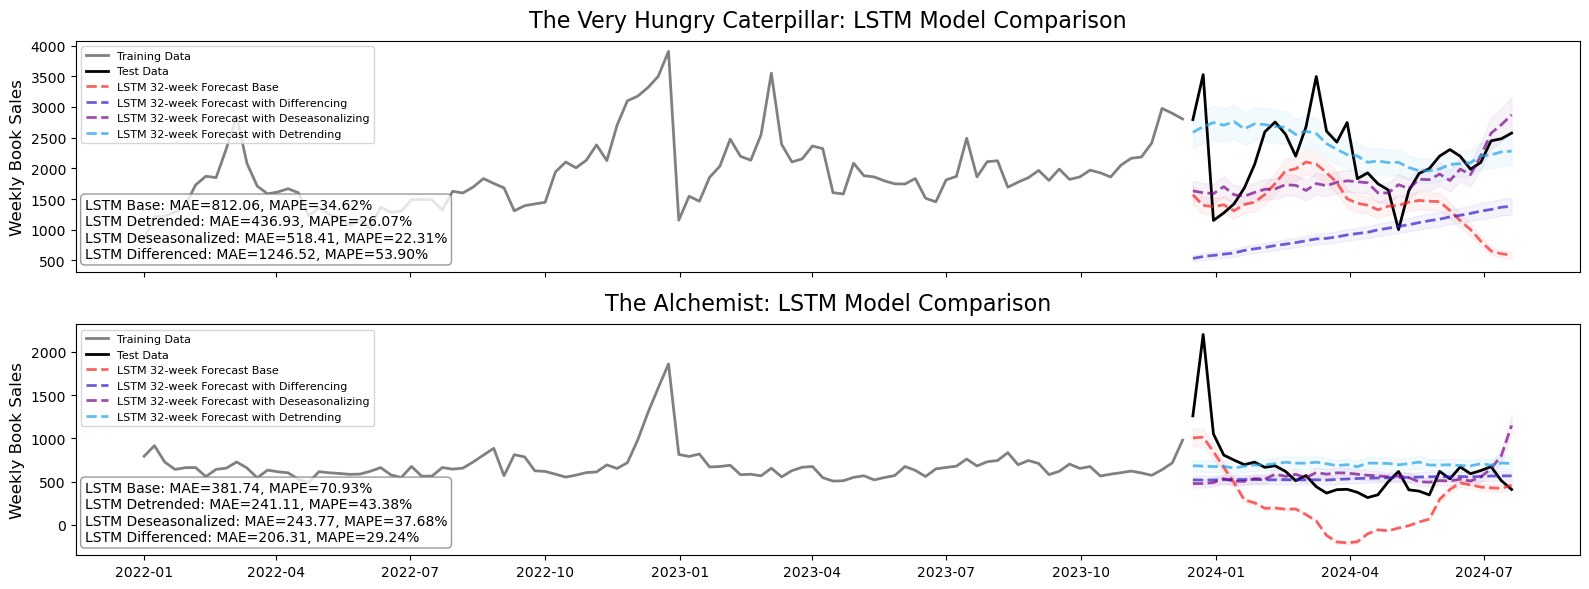

In [61]:

# Control the display period here
training_start_date = '2022-01-01'  # Change this to control what period is displayed

# Set up figure and subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(16, 6), sharex=True)
plt.subplots_adjust(hspace=0.4)

#====================== Plot The Very Hungry Caterpillar ============================================
# Training and test data - using training_start_date to control display period
ax1.plot(ts_train_hung_caterp[ts_train_hung_caterp.index >= training_start_date],
         label='Training Data', color='gray', linewidth=2)
ax1.plot(ts_test_hung_caterp[ts_test_hung_caterp.index >= training_start_date],
         label='Test Data', color='black', linewidth=2)

# Plot LSTM multi-step forecast
ax1.plot(predictions_df_hc_lstm_base.index, predictions_df_hc_lstm_base,
         label='LSTM 32-week Forecast Base',
         linestyle='--',
         linewidth=2,
         color="#f72222",
         alpha=0.7)
ax1.fill_between(predictions_df_hc_lstm_base.index,
                predictions_df_hc_lstm_base['Predictions'] * 0.9,
                predictions_df_hc_lstm_base['Predictions'] * 1.1,
                color='#f72222', alpha=0.05)


# LSTM Differencing predictions with individual styling - filtered by training_start_date
ax1.plot(predictions_df_hc_lstm_diff.index, predictions_df_hc_lstm_diff,
         label='LSTM 32-week Forecast with Differencing',
         linestyle='--',
         linewidth=2,
         color="#311ac9",
         alpha=0.7)
ax1.fill_between(predictions_df_hc_lstm_diff.index,
                 predictions_df_hc_lstm_diff['Predictions'] * 0.9,
                 predictions_df_hc_lstm_diff['Predictions'] * 1.1,
                 color='#311ac9', alpha=0.05)


# LSTM Deseasonalizing predictions with individual styling - filtered by training_start_date
ax1.plot(predictions_df_hc_lstm_deseason.index, predictions_df_hc_lstm_deseason,
         label='LSTM 32-week Forecast with Deseasonalizing',
         linestyle='--',
         linewidth=2,
         color="#740388",
         alpha=0.7)
ax1.fill_between(predictions_df_hc_lstm_deseason.index,
                 predictions_df_hc_lstm_deseason['Predictions'] * 0.9,
                 predictions_df_hc_lstm_deseason['Predictions'] * 1.1,
                 color='#740388', alpha=0.05)

# LSTM Detrend predictions with individual styling - filtered by training_start_date
ax1.plot(predictions_df_hc_lstm_detrend.index, predictions_df_hc_lstm_detrend,
         label='LSTM 32-week Forecast with Detrending',
         linestyle='--',
         linewidth=2,
         color="#1fa1e7",
         alpha=0.7)
ax1.fill_between(predictions_df_hc_lstm_detrend.index,
                 predictions_df_hc_lstm_detrend['Predictions'] * 0.9,
                 predictions_df_hc_lstm_detrend['Predictions'] * 1.1,
                 color='#1fa1e7', alpha=0.05)



# # Model predictions with individual styling - filtered by training_start_date
# test_dates_hc = ts_test_hung_caterp[ts_test_hung_caterp.index >= training_start_date].index

# # Plot each model's predictions
# models_hc = [
#     (predictions_week_lgbm_hc, 'Best LightGBM Model', '#06bb30')
# ]

# for pred, label, color in models_hc:
#     ax1.plot(test_dates_hc, pred[ts_test_hung_caterp.index >= training_start_date],
#              label=label,
#              linestyle='--',
#              linewidth=2,
#              color=color,
#              alpha=0.7)
#     ax1.fill_between(test_dates_hc,
#                     pred[ts_test_hung_caterp.index >= training_start_date] * 0.9,
#                     pred[ts_test_hung_caterp.index >= training_start_date] * 1.1,
#                     color=color, alpha=0.1)
    

# Calculate metrics for all models
metrics_text_hc = "\n".join([
    # calculate_model_metrics(ts_test_hung_caterp, predictions_week_lgbm_hc, "LightGBM Model"),
    calculate_model_metrics(ts_test_hung_caterp, predictions_df_hc_lstm_base, "LSTM Base"),
    calculate_model_metrics(ts_test_hung_caterp, predictions_df_hc_lstm_detrend, "LSTM Detrended"),
    calculate_model_metrics(ts_test_hung_caterp, predictions_df_hc_lstm_deseason, "LSTM Deseasonalized"),
    calculate_model_metrics(ts_test_hung_caterp, predictions_df_hc_lstm_diff, "LSTM Differenced")
])

ax1.annotate(metrics_text_hc, xy=(0.006, 0.32), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
             fontsize=10, va='top', ha='left')

# Formatting
ax1.set_title('The Very Hungry Caterpillar: LSTM Model Comparison', pad=10, fontsize=16)
ax1.set_ylabel('Weekly Book Sales', fontsize=12)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(False)

#====================== Plot The Alchemist ============================================
# Training and test data - using training_start_date to control display period
ax2.plot(ts_train_alchemist[ts_train_alchemist.index >= training_start_date],
         label='Training Data', color='gray', linewidth=2)
ax2.plot(ts_test_alchemist[ts_test_alchemist.index >= training_start_date],
         label='Test Data', color='black', linewidth=2)

# Plot LSTM multi-step forecast Base Model
ax2.plot(predictions_df_alchemist_lstm_base.index, predictions_df_alchemist_lstm_base,
         label='LSTM 32-week Forecast Base',
         linestyle='--',
         linewidth=2,
         color="#f72222",
         alpha=0.7)
ax2.fill_between(predictions_df_alchemist_lstm_base.index,
                 predictions_df_alchemist_lstm_base['Predictions'] * 0.9,
                 predictions_df_alchemist_lstm_base['Predictions'] * 1.1,
                 color='#f72222', alpha=0.05)


# LSTM Differencing predictions with individual styling - filtered by training_start_date
ax2.plot(predictions_df_alchemist_lstm_diff.index, predictions_df_alchemist_lstm_diff,
         label='LSTM 32-week Forecast with Differencing',
         linestyle='--',
         linewidth=2,
         color="#311ac9",
         alpha=0.7)
ax2.fill_between(predictions_df_alchemist_lstm_diff.index,
                 predictions_df_alchemist_lstm_diff['Predictions'] * 0.9,
                 predictions_df_alchemist_lstm_diff['Predictions'] * 1.1,
                 color='#311ac9', alpha=0.05)


# LSTM Deseasonalizing predictions with individual styling - filtered by training_start_date
ax2.plot(predictions_df_alchemist_lstm_deseasonalize.index, predictions_df_alchemist_lstm_deseasonalize,
         label='LSTM 32-week Forecast with Deseasonalizing',
         linestyle='--',
         linewidth=2,
         color="#740388",
         alpha=0.7)
ax2.fill_between(predictions_df_alchemist_lstm_deseasonalize.index,
                 predictions_df_alchemist_lstm_deseasonalize['Predictions'] * 0.9,
                 predictions_df_alchemist_lstm_deseasonalize['Predictions'] * 1.1,
                 color='#740388', alpha=0.05)

# LSTM Detrend predictions with individual styling - filtered by training_start_date
ax2.plot(predictions_df_alchemist_lstm_detrend.index, predictions_df_alchemist_lstm_detrend,
         label='LSTM 32-week Forecast with Detrending',
         linestyle='--',
         linewidth=2,
         color="#1fa1e7",
         alpha=0.7)
ax2.fill_between(predictions_df_alchemist_lstm_detrend.index,
                 predictions_df_alchemist_lstm_detrend['Predictions'] * 0.9,
                 predictions_df_alchemist_lstm_detrend['Predictions'] * 1.1,
                 color='#1fa1e7', alpha=0.05)



# # Model predictions with individual styling - filtered by training_start_date
# test_dates_alchemist = ts_test_alchemist[ts_test_alchemist.index >= training_start_date].index

# # Plot each model's predictions
# models_alchemist = [
#     (predictions_week_lgbm_alchemist, 'Best LightGBM Model', '#06bb30')
# ]

# for pred, label, color in models_alchemist:
#     ax2.plot(test_dates_alchemist, pred[ts_test_alchemist.index >= training_start_date],
#              label=label,
#              linestyle='--',
#              linewidth=2,
#              color=color,
#              alpha=0.7)
#     ax2.fill_between(test_dates_alchemist,
#                     pred[ts_test_alchemist.index >= training_start_date] * 0.9,
#                     pred[ts_test_alchemist.index >= training_start_date] * 1.1,
#                     color=color, alpha=0.1)
    

# Calculate metrics for all models
metrics_text_alchemist = "\n".join([
    # calculate_model_metrics(ts_test_alchemist, predictions_week_lgbm_alchemist, "LightGBM Model"),
    calculate_model_metrics(ts_test_alchemist, predictions_df_alchemist_lstm_base, "LSTM Base"),
    calculate_model_metrics(ts_test_alchemist, predictions_df_alchemist_lstm_detrend, "LSTM Detrended"),
    calculate_model_metrics(ts_test_alchemist, predictions_df_alchemist_lstm_deseasonalize, "LSTM Deseasonalized"),
    calculate_model_metrics(ts_test_alchemist, predictions_df_alchemist_lstm_diff, "LSTM Differenced")
])

ax2.annotate(metrics_text_alchemist, xy=(0.006, 0.32), xycoords='axes fraction',
             bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8),
             fontsize=10, va='top', ha='left')

# Formatting
ax2.set_title('The Alchemist: LSTM Model Comparison', pad=10, fontsize=16)
ax2.set_ylabel('Weekly Book Sales', fontsize=12)
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(False)


plt.tight_layout()
plt.show()

Base LSTM MODEL TRAINING REPORT

TRAINING PERFORMANCE:
----------------------------------------
loss: Final=0.0092, Best=0.0090
mae: Final=0.0674, Best=0.1866

VALIDATION PERFORMANCE:
----------------------------------------
val_loss: Final=0.0632, Best=0.0288
val_mae: Final=0.1822, Best=0.1974

PERFORMANCE VISUALIZATION:


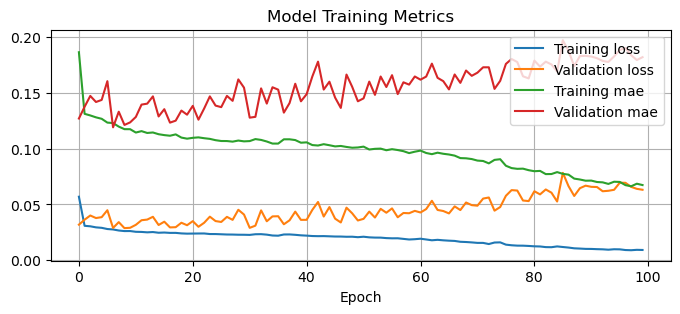

Detrended LSTM MODEL TRAINING REPORT

TRAINING PERFORMANCE:
----------------------------------------
loss: Final=0.0177, Best=0.0175
mae: Final=0.0921, Best=0.2073
lr: Final=0.0002, Best=0.0010

VALIDATION PERFORMANCE:
----------------------------------------
val_loss: Final=0.0216, Best=0.0185
val_mae: Final=0.1136, Best=0.1245

PERFORMANCE VISUALIZATION:


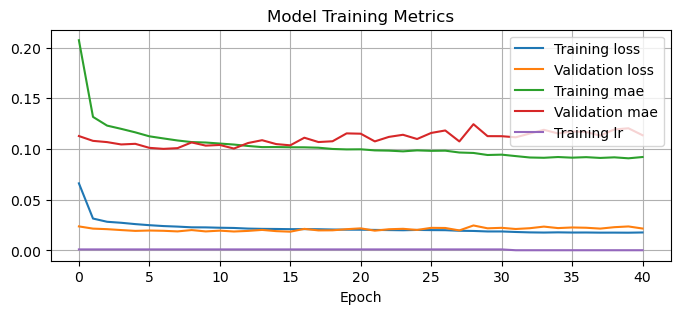

Deseasonalized LSTM MODEL TRAINING REPORT

TRAINING PERFORMANCE:
----------------------------------------
loss: Final=0.0110, Best=0.0108
mae: Final=0.0776, Best=0.2103
lr: Final=0.0002, Best=0.0010

VALIDATION PERFORMANCE:
----------------------------------------
val_loss: Final=0.0131, Best=0.0109
val_mae: Final=0.0825, Best=0.1154

PERFORMANCE VISUALIZATION:


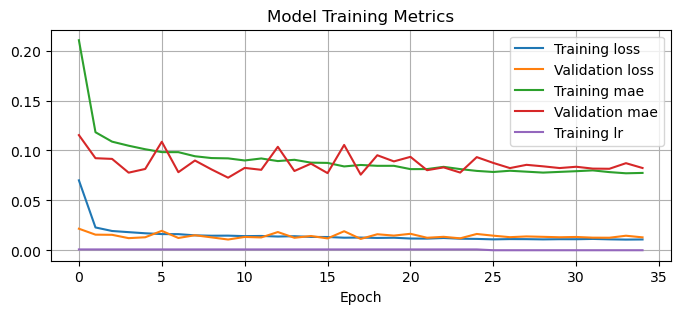

Differenced LSTM MODEL TRAINING REPORT

TRAINING PERFORMANCE:
----------------------------------------
loss: Final=0.0061, Best=0.0061
mae: Final=0.0520, Best=0.2379
lr: Final=0.0000, Best=0.0010

VALIDATION PERFORMANCE:
----------------------------------------
val_loss: Final=0.0053, Best=0.0053
val_mae: Final=0.0429, Best=0.0681

PERFORMANCE VISUALIZATION:


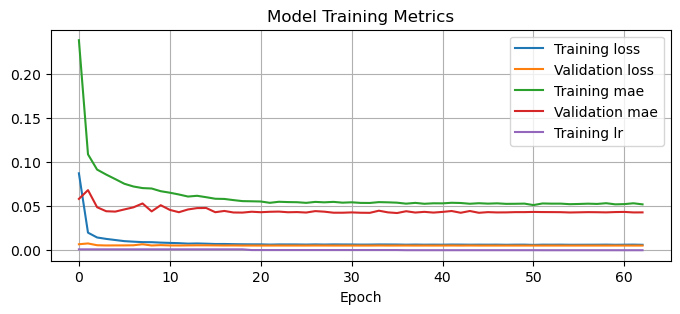

In [43]:
def generate_lstm_performance_report(history, model_name="LSTM"):
    """Generate performance report from LSTM training history"""
    
    history_dict = history.history
    
    print("="*60)
    print(f"{model_name} MODEL TRAINING REPORT")
    print("="*60)
    
    # Extract available metrics
    metrics = [k for k in history_dict.keys() if not k.startswith('val_')]
    val_metrics = [k for k in history_dict.keys() if k.startswith('val_')]
    
    # Training statistics
    print("\nTRAINING PERFORMANCE:")
    print("-"*40)
    for metric in metrics:
        final_value = history_dict[metric][-1]
        best_value = min(history_dict[metric]) if 'loss' in metric else max(history_dict[metric])
        print(f"{metric}: Final={final_value:.4f}, Best={best_value:.4f}")
    
    # Validation statistics (if available)
    if val_metrics:
        print("\nVALIDATION PERFORMANCE:")
        print("-"*40)
        for metric in val_metrics:
            final_value = history_dict[metric][-1]
            best_value = min(history_dict[metric]) if 'loss' in metric else max(history_dict[metric])
            print(f"{metric}: Final={final_value:.4f}, Best={best_value:.4f}")
    
    # Early stopping info
    if hasattr(history, 'stopped_epoch') and history.stopped_epoch > 0:
        print(f"\nTraining stopped early at epoch {history.stopped_epoch}")
    
    # Plotting metrics
    print("\nPERFORMANCE VISUALIZATION:")
    plt.figure(figsize=(8, 3))
    for metric in metrics:
        plt.plot(history_dict[metric], label=f'Training {metric}')
        val_metric = f'val_{metric}'
        if val_metric in history_dict:
            plt.plot(history_dict[val_metric], label=f'Validation {metric}')
    plt.title('Model Training Metrics')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

# Usage example:
generate_lstm_performance_report(history_hc_lstm_base, "Base LSTM")
generate_lstm_performance_report(history_hc_lstm_detrend, "Detrended LSTM")
generate_lstm_performance_report(history_hc_lstm_deseason, "Deseasonalized LSTM")
generate_lstm_performance_report(history_hc_lstm_diff, "Differenced LSTM")